In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Amaan\OneDrive\Desktop\telecom\Customer-Churn-Prediction-Lifetime-Value-Engine\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

print("Dataset shape:", df.shape)

Dataset shape: (7032, 21)


In [11]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

# Convert categorical variables into numeric features
X = pd.get_dummies(X, drop_first=True)

# Make sure all values are numeric
X = X.astype(float)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 7061)
Target: (7032,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 7061)
X_test: (1407, 7061)
y_train: (5625,)
y_test: (1407,)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Create models
logistic_model = LogisticRegression(max_iter=1000)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
gradient_boosting = GradientBoostingClassifier(random_state=42)

# Train models
logistic_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)

print("Models trained successfully!")

c:\Users\Amaan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained successfully!


In [15]:

feature_names = X_train.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Decision Tree": decision_tree.feature_importances_,
    "Random Forest": random_forest.feature_importances_,
    "Gradient Boosting": gradient_boosting.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Random Forest",
    ascending=False
)

feature_importance.head(10)

,Feature,Decision Tree,Random Forest,Gradient Boosting
3,TotalCharges,0.111986,0.103251,0.024055
1,tenure,0.172873,0.095547,0.319632
2,MonthlyCharges,0.081938,0.081871,0.027994
7041,InternetService_Fiber optic,0.107916,0.027049,0.196635
7056,Contract_Two year,0.008737,0.026796,0.071379
7059,PaymentMethod_Electronic check,0.014867,0.023906,0.107357
7044,OnlineSecurity_Yes,0.015391,0.020915,0.019380
7050,TechSupport_Yes,0.011077,0.018321,0.009268
7055,Contract_One year,0.008335,0.017366,0.059114
7057,PaperlessBilling_Yes,0.008678,0.017309,0.013326


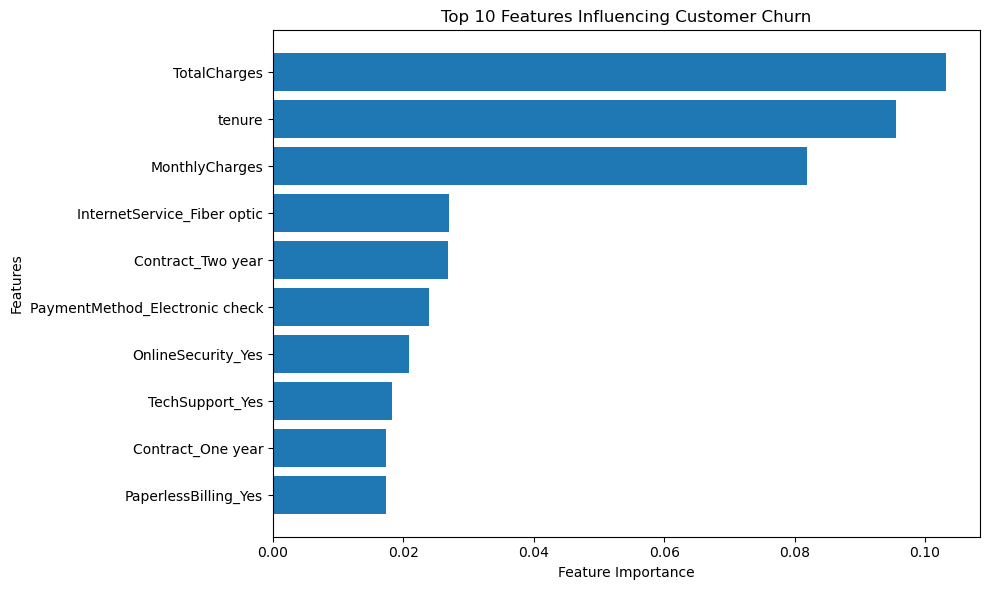

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Random Forest"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing Customer Churn")
plt.tight_layout()
plt.show()

In [17]:
top_features = feature_importance.head(10)

print("Top 10 Features Influencing Customer Churn:\n")

for i, row in enumerate(top_features.itertuples(index=False), 1):
    print(f"{i}. {row.Feature}")

Top 10 Features Influencing Customer Churn:

1. TotalCharges
2. tenure
3. MonthlyCharges
4. InternetService_Fiber optic
5. Contract_Two year
6. PaymentMethod_Electronic check
7. OnlineSecurity_Yes
8. TechSupport_Yes
9. Contract_One year
10. PaperlessBilling_Yes
